In [1]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
tokenizer

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

DistilBertTokenizerFast(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [2]:
!pip install datasets

In [3]:
from datasets import load_dataset


dataset = load_dataset("mstz/bank", "subscription")["train"]

README.md:   0%|          | 0.00/2.13k [00:00<?, ?B/s]

bank.py:   0%|          | 0.00/5.50k [00:00<?, ?B/s]

The repository for mstz/bank contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/mstz/bank.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N]  y


Generating train split: 0 examples [00:00, ? examples/s]

In [4]:
!wget https://archive.ics.uci.edu/static/public/222/bank+marketing.zip
!unzip bank+marketing.zip
!unzip bank.zip

--2025-02-13 13:33:13--  https://archive.ics.uci.edu/static/public/222/bank+marketing.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘bank+marketing.zip’

bank+marketing.zip      [ <=>                ] 999.85K  6.18MB/s    in 0.2s    

2025-02-13 13:33:13 (6.18 MB/s) - ‘bank+marketing.zip’ saved [1023843]

Archive:  bank+marketing.zip
 extracting: bank.zip                
 extracting: bank-additional.zip     
Archive:  bank.zip
  inflating: bank-full.csv           
  inflating: bank-names.txt          
  inflating: bank.csv                


In [5]:
import pandas as pd

df = pd.read_csv('bank-full.csv', sep=';').drop('duration', axis = 1)
print(len(df))
df.head()

45211


,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,-1,0,unknown,no


In [30]:
import numpy as np
import torch

def concatenate_text(x):
    return f"{x['age']}, {x['job']}, {x['marital']}, {x['education']}, {x['balance']}, {x['default']}, {x['housing']}, {x['loan']}, {x['day']}, {x['month']}, {x['contact']}, {x['campaign']}, {x['previous']}, {x['pdays']}, {x['poutcome']},"


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('y', axis =1),
                                                    df['y'],
                                                    test_size=.2,
                                                    random_state = 42)
y_train = y_train.replace({'yes': 1, 'no': 0})
y_test = y_test.replace({'yes': 1, 'no': 0})

X_train['label'] = y_train
X_test['label'] = y_test

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

<ipython-input-31-adc7229c10d8>:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train = y_train.replace({'yes': 1, 'no': 0})
<ipython-input-31-adc7229c10d8>:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_test = y_test.replace({'yes': 1, 'no': 0})


In [32]:
X_train['text'].iloc[0]

'41, blue-collar, married, primary, 849, no, yes, no, 15, may, unknown, 1, 0, -1, unknown,'

In [33]:
len(X_train)

36168

In [34]:
!pip install evaluate

In [35]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import numpy as np
import evaluate

# Define label mappings
id2label = {0: "NOT-SUBSCRIBE", 1: "SUBSCRIBE"}
label2id = {"NOT-SUBSCRIBE": 0, "SUBSCRIBE": 1}

# Convert to Hugging Face Dataset format
train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

def tokenize_function(examples):
    # Adjust based on the structure of your dataset
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

Map:   0%|          | 0/36168 [00:00<?, ? examples/s]

Map:   0%|          | 0/9043 [00:00<?, ? examples/s]

Map:   0%|          | 0/36168 [00:00<?, ? examples/s]

Map:   0%|          | 0/9043 [00:00<?, ? examples/s]

In [36]:
tokenized_train_dataset[0].keys()

dict_keys(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome', 'label', 'text', '__index_level_0__', 'input_ids', 'attention_mask', 'labels'])

In [37]:
tokenized_train_dataset[0]['text']

'41, blue-collar, married, primary, 849, no, yes, no, 15, may, unknown, 1, 0, -1, unknown,'

In [38]:
tokenized_train_dataset[0]['label']

0

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Roc Auc
1,0.318100,0.327193,0.729254
2,0.314100,0.334831,0.738193
3,0.341200,0.327069,0.743467
4,0.294500,0.316357,0.744032
5,0.263900,0.314660,0.746386


{'eval_loss': 0.3146599531173706, 'eval_roc_auc': 0.7463860846103201, 'eval_runtime': 17.4965, 'eval_samples_per_second': 516.846, 'eval_steps_per_second': 8.116, 'epoch': 5.0}
test f1 0.2815033161385409
test precision 0.7180451127819549
test recall 0.17506874427131072
test accuracy 0.7180451127819549
test roc_auc 0.7460009829831418



train f1 0.26162120630042257
train precision 0.6755952380952381
train recall 0.16222010481181515
train accuracy 0.893718203937182
train roc_auc 0.7594959349545034


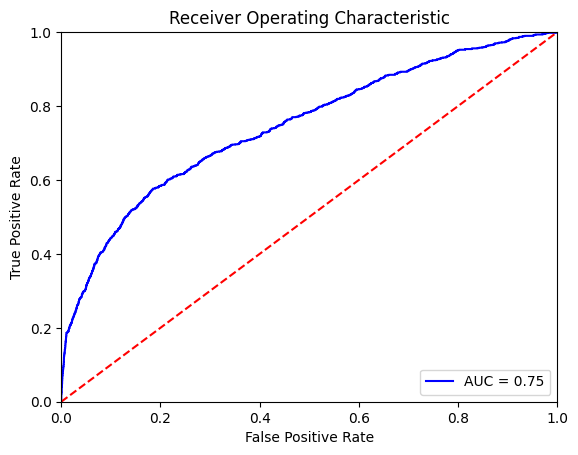

In [39]:
from transformers import DistilBertForSequenceClassification
from transformers import DataCollatorWithPadding
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import roc_curve, auc
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import sklearn.metrics as metrics

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2).to('cuda')

for param in model.distilbert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    learning_rate = 0.001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

Epoch,Training Loss,Validation Loss,Roc Auc
1,0.306300,0.318350,0.767696
2,0.298700,0.303725,0.775350
3,0.320900,0.302248,0.791574
4,0.274600,0.298886,0.790303
5,0.213100,0.301924,0.793327
6,0.260700,0.303919,0.795297
7,0.269600,0.300114,0.793711
8,0.253600,0.298189,0.793584
9,0.239600,0.301239,0.791154
10,0.236000,0.307533,0.789578


{'eval_loss': 0.30753272771835327, 'eval_roc_auc': 0.7895783269737582, 'eval_runtime': 17.5834, 'eval_samples_per_second': 514.291, 'eval_steps_per_second': 8.076, 'epoch': 10.0}
test f1 0.40503295386458954
test precision 0.5847750865051903
test recall 0.30980751604032997
test accuracy 0.5847750865051903
test roc_auc 0.7901531554127699



train f1 0.4982498858621215
train precision 0.6898440792246102
train recall 0.38994759409242497
train accuracy 0.9088420703384207
train roc_auc 0.8730535550017635


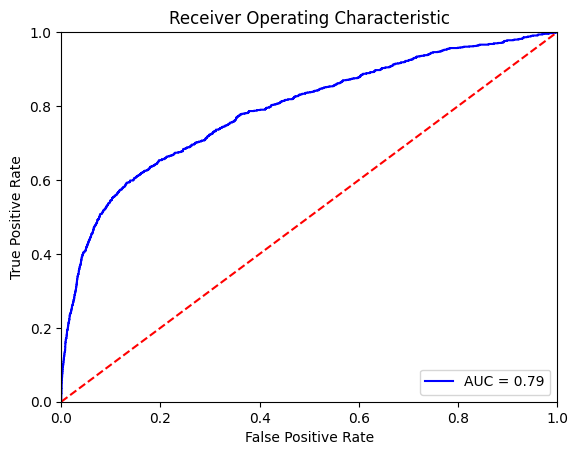

In [41]:
for param in model.distilbert.parameters():
    param.requires_grad = True

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [24]:
def concatenate_text(x):
    if x['default'] == 'yes':
      df = 'he has a credit in default'
    else:
      df = 'he does not have credits in default'

    if x['housing'] == 'yes':
      hs = 'he has a housing loan'
    else:
      hs = 'he does not have a housing loan'

    if x['loan'] == 'yes':
      ln = 'he has a personal loan'
    else:
      ln = 'he does not have a personal loan'

    if x['pdays'] == -1:
      prev = 'we have not contacted him previously'
    else:
      prev = f'previously we have contacted him {x["previous"]} times, the last time was {x["pdays"]} before, and it was {x["poutcome"]}'


    full_text = (
        f"This customer age is {x['age']} years old, "
        f"his job is {x['job']}, ",
        f"his marital status is {x['marital']}, ",
        f"his education is {x['education']}, ",
        f"his average yearly balance is {x['balance']} euros, ",
        f"{df}, ",
        f"{hs}, ",
        f"{ln}, ",
        f"our last contact to him was on {x['day']}th of {x['month']}, the contact communication type was {x['contact']}, ",
        f"during this campaign we have called him {x['campaign']} times, ",
        f"{prev}.",
    )
    return ''.join(full_text)

X_train, X_test, y_train, y_test = train_test_split(df.drop('y', axis =1),
                                                    df['y'],
                                                    test_size=.2,
                                                    random_state = 42)
y_train = y_train.replace({'yes': 1, 'no': 0})
y_test = y_test.replace({'yes': 1, 'no': 0})

X_train['label'] = y_train
X_test['label'] = y_test

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

# Define label mappings
id2label = {0: "NOT-SUBSCRIBE", 1: "SUBSCRIBE"}
label2id = {"NOT-SUBSCRIBE": 0, "SUBSCRIBE": 1}

# Convert to Hugging Face Dataset format
train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

def tokenize_function(examples):
    # Adjust based on the structure of your dataset
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

for param in model.distilbert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    learning_rate = 0.001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))

fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

<ipython-input-24-b3cf6865b969>:42: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train = y_train.replace({'yes': 1, 'no': 0})
<ipython-input-24-b3cf6865b969>:43: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_test = y_test.replace({'yes': 1, 'no': 0})


Map:   0%|          | 0/36168 [00:00<?, ? examples/s]

Map:   0%|          | 0/9043 [00:00<?, ? examples/s]

Map:   0%|          | 0/36168 [00:00<?, ? examples/s]

Map:   0%|          | 0/9043 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Roc Auc
1,0.317800,0.338365,0.684220
2,0.328500,0.352952,0.700293
3,0.346600,0.342417,0.709614
4,0.298400,0.328825,0.708582
5,0.262400,0.327380,0.714624


{'eval_loss': 0.3273797333240509, 'eval_roc_auc': 0.7146237300060676, 'eval_runtime': 17.5433, 'eval_samples_per_second': 515.466, 'eval_steps_per_second': 8.094, 'epoch': 5.0}
test f1 0.2830188679245283
test precision 0.6794425087108014
test recall 0.17873510540788268
test accuracy 0.6794425087108014
test roc_auc 0.7142563792470682



KeyboardInterrupt: 

Epoch,Training Loss,Validation Loss,Roc Auc
1,0.316300,0.308567,0.763685
2,0.301100,0.300669,0.778528
3,0.325400,0.300098,0.790995
4,0.269800,0.298748,0.789280
5,0.216600,0.295824,0.795219
6,0.263700,0.297421,0.797146
7,0.275300,0.292393,0.799897
8,0.263100,0.290831,0.800296
9,0.245600,0.291765,0.799451
10,0.228300,0.293042,0.799912


{'eval_loss': 0.2930420935153961, 'eval_roc_auc': 0.7999115222960125, 'eval_runtime': 17.6299, 'eval_samples_per_second': 512.937, 'eval_steps_per_second': 8.055, 'epoch': 10.0}
test f1 0.41267942583732053
test precision 0.5938037865748709
test recall 0.3162236480293309
test accuracy 0.5938037865748709
test roc_auc 0.7998586154876093



train f1 0.46660510926438903
train precision 0.6591304347826087
train recall 0.3611243449261553
train accuracy 0.9041694315416943
train roc_auc 0.8463540736067028


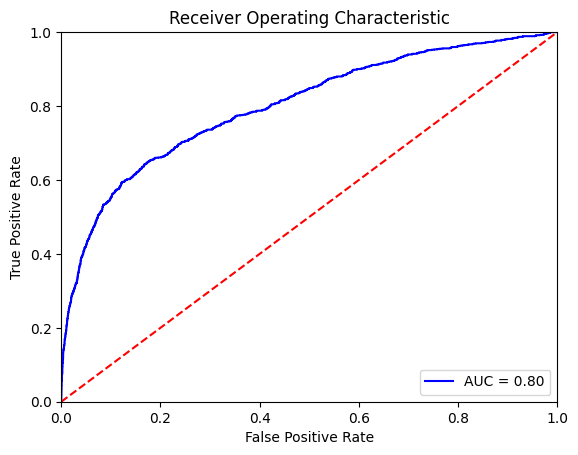

In [26]:
for param in model.distilbert.parameters():
    param.requires_grad = True

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

<ipython-input-43-b3cf6865b969>:42: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train = y_train.replace({'yes': 1, 'no': 0})
<ipython-input-43-b3cf6865b969>:43: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_test = y_test.replace({'yes': 1, 'no': 0})


Map:   0%|          | 0/36168 [00:00<?, ? examples/s]

Map:   0%|          | 0/9043 [00:00<?, ? examples/s]

Map:   0%|          | 0/36168 [00:00<?, ? examples/s]

Map:   0%|          | 0/9043 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Roc Auc
1,0.320600,0.336548,0.684973
2,0.323700,0.348171,0.700057
3,0.350700,0.345290,0.708067
4,0.302100,0.328209,0.709059
5,0.260800,0.327352,0.714913


{'eval_loss': 0.3273519277572632, 'eval_roc_auc': 0.7149133342677514, 'eval_runtime': 17.5636, 'eval_samples_per_second': 514.872, 'eval_steps_per_second': 8.085, 'epoch': 5.0}
test f1 0.2830188679245283
test precision 0.6794425087108014
test recall 0.17873510540788268
test accuracy 0.6794425087108014
test roc_auc 0.7149242844786409



train f1 0.2795216741405082
train precision 0.6481802426343154
train recall 0.17818008575512148
train accuracy 0.8933864189338642
train roc_auc 0.7315325393640388


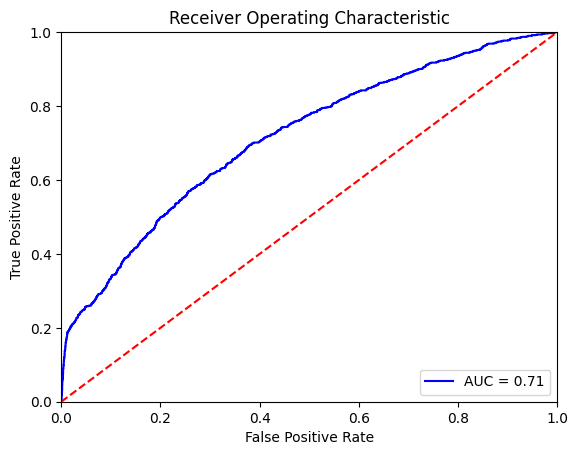

In [43]:
def concatenate_text(x):
    if x['default'] == 'yes':
      df = 'he has a credit in default'
    else:
      df = 'he does not have credits in default'

    if x['housing'] == 'yes':
      hs = 'he has a housing loan'
    else:
      hs = 'he does not have a housing loan'

    if x['loan'] == 'yes':
      ln = 'he has a personal loan'
    else:
      ln = 'he does not have a personal loan'

    if x['pdays'] == -1:
      prev = 'we have not contacted him previously'
    else:
      prev = f'previously we have contacted him {x["previous"]} times, the last time was {x["pdays"]} before, and it was {x["poutcome"]}'


    full_text = (
        f"This customer age is {x['age']} years old, "
        f"his job is {x['job']}, ",
        f"his marital status is {x['marital']}, ",
        f"his education is {x['education']}, ",
        f"his average yearly balance is {x['balance']} euros, ",
        f"{df}, ",
        f"{hs}, ",
        f"{ln}, ",
        f"our last contact to him was on {x['day']}th of {x['month']}, the contact communication type was {x['contact']}, ",
        f"during this campaign we have called him {x['campaign']} times, ",
        f"{prev}.",
    )
    return ''.join(full_text)

X_train, X_test, y_train, y_test = train_test_split(df.drop('y', axis =1),
                                                    df['y'],
                                                    test_size=.2,
                                                    random_state = 42)
y_train = y_train.replace({'yes': 1, 'no': 0})
y_test = y_test.replace({'yes': 1, 'no': 0})

X_train['label'] = y_train
X_test['label'] = y_test

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

# Define label mappings
id2label = {0: "NOT-SUBSCRIBE", 1: "SUBSCRIBE"}
label2id = {"NOT-SUBSCRIBE": 0, "SUBSCRIBE": 1}

# Convert to Hugging Face Dataset format
train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

def tokenize_function(examples):
    # Adjust based on the structure of your dataset
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

for param in model.distilbert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    learning_rate = 0.001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))

fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [ ]:
for param in model.distilbert.parameters():
    param.requires_grad = True

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [ ]:
from transformers import DistilBertForMaskedLM
from tqdm import tqdm

pred = []

masked_lm_model = DistilBertForMaskedLM.from_pretrained('distilbert-base-uncased')

for doc in tqdm(range(len(tokenized_test_dataset))):
  text = tokenizer.encode(tokenized_test_dataset[doc]['text'] + "Has the marketing campaign succeded for him? Answer: [MASK].")
  yes_token = tokenizer.encode('yes')[1]
  no_token = tokenizer.encode('no')[1]
  mask_token = tokenizer.encode('[MASK]')[1]
  masked_index = text.index(mask_token)

  logits = masked_lm_model(torch.tensor([text]))['logits']

  if logits[0, masked_index, yes_token] > logits[0, masked_index, no_token]:
    pred.append(1)
  else:
    pred.append(0)

100%|██████████| 9043/9043 [43:10<00:00,  3.49it/s]


In [ ]:
print("f1_test", f1_score(y_test, pred))
print("precision_test", precision_score(y_test, pred))
print("recall_test", recall_score(y_test, pred))
print("accuracy_test", accuracy_score(y_test, pred))

f1_test 0.22860425043078691
precision_test 0.30615384615384617
recall_test 0.18240146654445463
accuracy_test 0.8514873382726971


In [ ]:
y_test.mean()

0.1206458033838328

In [ ]:
pred_train[0]

array([[ 1.6105785, -1.5765104],
       [ 1.1122532, -1.0826808],
       [ 1.0149872, -0.9930794],
       ...,
       [ 1.1095079, -1.0800537],
       [ 1.5339566, -1.5050093],
       [ 1.2603791, -1.2331339]], dtype=float32)

In [ ]:
def concatenate_text(x):
    if x['default'] == 'yes':
      df = 'he has a credit in default'
    else:
      df = 'he does not have credits in default'

    if x['housing'] == 'yes':
      hs = 'he has a housing loan'
    else:
      hs = 'he does not have a housing loan'

    if x['loan'] == 'yes':
      ln = 'he has a personal loan'
    else:
      ln = 'he does not have a personal loan'

    if x['pdays'] == -1:
      prev = 'we have not contacted him previously'
    else:
      prev = f'previously we have contacted him {x["previous"]} times, the last time was {x["pdays"]} before, and it was {x["poutcome"]}'


    full_text = (
        f"This customer age is {x['age']} years old, "
        f"his job is {x['job']}, ",
        f"his marital status is {x['marital']}, ",
        f"his education is {x['education']}, ",
        f"his average yearly balance is {x['balance']} euros, ",
        f"{df}, ",
        f"{hs}, ",
        f"{ln}, ",
        f"our last contact to him was on {x['day']}th of {x['month']}, the contact communication type was {x['contact']}, ",
        f"during this campaign we have called him {x['campaign']} times, ",
        f"{prev}.",
    )
    return ''.join(full_text)

X_train, X_test, y_train, y_test = train_test_split(df.drop('y', axis =1),
                                                    df['y'],
                                                    test_size=.2,
                                                    random_state = 42)
y_train = y_train.replace({'yes': 1, 'no': 0})
y_test = y_test.replace({'yes': 1, 'no': 0})

X_train['label'] = y_train
X_test['label'] = y_test

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

# Define label mappings
id2label = {0: "NOT-SUBSCRIBE", 1: "SUBSCRIBE"}
label2id = {"NOT-SUBSCRIBE": 0, "SUBSCRIBE": 1}

# Convert to Hugging Face Dataset format
train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

def tokenize_function(examples):
    # Adjust based on the structure of your dataset
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

<ipython-input-16-c80c4b577929>:42: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train = y_train.replace({'yes': 1, 'no': 0})
<ipython-input-16-c80c4b577929>:43: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_test = y_test.replace({'yes': 1, 'no': 0})


Map:   0%|          | 0/36168 [00:00<?, ? examples/s]

Map:   0%|          | 0/9043 [00:00<?, ? examples/s]

Map:   0%|          | 0/36168 [00:00<?, ? examples/s]

Map:   0%|          | 0/9043 [00:00<?, ? examples/s]

100%|██████████| 9043/9043 [01:23<00:00, 108.71it/s]


f1_test 0.22860425043078691
precision_test 0.30615384615384617
recall_test 0.18240146654445463
accuracy_test 0.8514873382726971
test roc_auc 0.5482952135360282


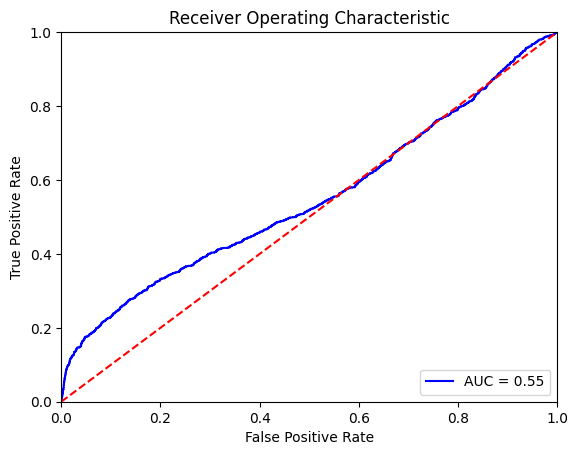

In [ ]:
from transformers import DistilBertForMaskedLM
from tqdm import tqdm

pred = []
yes_logits = []
no_logits = []

masked_lm_model = DistilBertForMaskedLM.from_pretrained('distilbert-base-uncased').to('cuda')
yes_token = tokenizer.encode('yes')[1]
no_token = tokenizer.encode('no')[1]
mask_token = tokenizer.encode('[MASK]')[1]
masked_lm_model.eval()

with torch.no_grad():
  for doc in tqdm(range(len(tokenized_test_dataset))):
    text = tokenizer(tokenized_test_dataset[doc]['text'] + "Has the marketing campaign succeded for him? Answer: [MASK].", return_tensors='pt').to('cuda')

    masked_index = (text.input_ids == mask_token).nonzero(as_tuple=True)[1].item()

    # input = torch.tensor([text]).to('cuda')
    logits = masked_lm_model(**text)['logits']
    # torch.cuda.empty_cache()

    yes_logits.append(logits[0, masked_index, yes_token].to('cpu'))
    no_logits.append(logits[0, masked_index, no_token].to('cpu'))

    if logits[0, masked_index, yes_token] > logits[0, masked_index, no_token]:
      pred.append(1)
    else:
      pred.append(0)

    # del logits

print("f1_test", f1_score(y_test, pred))
print("precision_test", precision_score(y_test, pred))
print("recall_test", recall_score(y_test, pred))
print("accuracy_test", accuracy_score(y_test, pred))

probas = []

for yes, no in zip(yes_logits, no_logits):
  probas.append(softmax([yes, no])[0])

fpr, tpr, threshold = roc_curve(y_test, probas)
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [ ]:
from transformers import DistilBertForMaskedLM
from tqdm import tqdm

pred = []
yes_logits = []
no_logits = []

masked_lm_model = DistilBertForMaskedLM.from_pretrained('distilbert-base-uncased').to('cuda')
yes_token = tokenizer.encode('yes')[1]
no_token = tokenizer.encode('no')[1]
mask_token = tokenizer.encode('[MASK]')[1]
masked_lm_model.eval()

with torch.no_grad():
  for doc in tqdm(range(len(tokenized_test_dataset))):
    text = tokenizer(tokenized_test_dataset[doc]['text'] + "Has the marketing campaign succeded for him? Yes or no? Answer: [MASK].", return_tensors='pt').to('cuda')

    masked_index = (text.input_ids == mask_token).nonzero(as_tuple=True)[1].item()

    # input = torch.tensor([text]).to('cuda')
    logits = masked_lm_model(**text)['logits']
    # torch.cuda.empty_cache()

    yes_logits.append(logits[0, masked_index, yes_token].to('cpu'))
    no_logits.append(logits[0, masked_index, no_token].to('cpu'))

    if logits[0, masked_index, yes_token] > logits[0, masked_index, no_token]:
      pred.append(1)
    else:
      pred.append(0)

    # del logits

100%|██████████| 9043/9043 [01:17<00:00, 116.17it/s]


In [ ]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import roc_curve, auc
import sklearn.metrics as metrics

print("f1_test", f1_score(y_test, pred))
print("precision_test", precision_score(y_test, pred))
print("recall_test", recall_score(y_test, pred))
print("accuracy_test", accuracy_score(y_test, pred))

f1_test 0.2151710461080813
precision_test 0.12063597954191684
recall_test 0.9945004582951421
accuracy_test 0.12473736591838991


In [ ]:
from scipy.special import softmax

probas = []

for yes, no in zip(yes_logits, no_logits):
  probas.append(softmax([yes, no])[0])

test roc_auc 0.5180894025933788


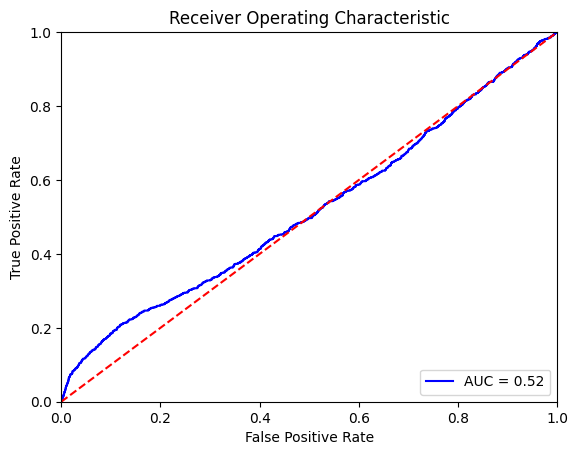

In [ ]:
import matplotlib.pyplot as plt

fpr, tpr, threshold = roc_curve(y_test, probas)
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()